# 03 — Análisis de Tendencias (Fase 2C)

Por cada serie: regresión lineal (pendiente /mes, R², error residual) y clasificación automática en **Mejorando / Estable / Empeorando / Oscilante**. El signo se interpreta clínicamente (p. ej. glucosa con pendiente negativa → *Mejorando*).

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

TCF = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TCF / "src"))
from predia_temporal import config
DS, MET, FIG, DASH = TCF/"datasets", TCF/"metrics", TCF/"figures", TCF/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)
print("Entorno listo:", TCF)


Entorno listo: /home/wowo/Descargas/predia/ml-research/temporal_clinical_framework


In [2]:
tr = pd.read_csv(MET/'trends.csv'); meta = pd.read_csv(DS/'cohort_meta.csv')
pd.crosstab(tr.variable, tr.trend)

trend,Empeorando,Estable,Mejorando,Oscilante
variable,,,,
glucosa,123,152,68,57
imc,91,235,74,0
pad,89,235,76,0
pas,120,204,70,6
peso,139,189,72,0
riesgo,108,69,68,155


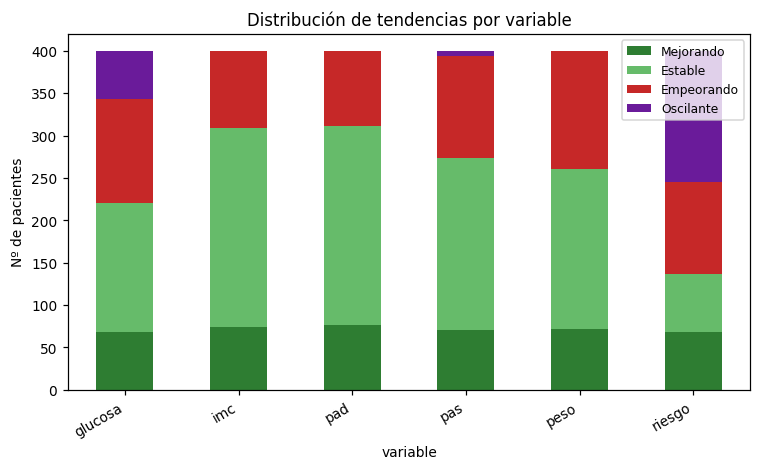

In [3]:
show(FIG/'trends'/'trend_distribution.png')

## La clasificación recupera la dinámica real
Cruzando la tendencia de glucosa con el arquetipo verdadero: *Deterioro* → Empeorando, *Mejora rápida* → Mejorando, *Oscilante* → Oscilante.

In [4]:
g = tr[tr.variable=='glucosa'].merge(meta[['patient_id','archetype']],on='patient_id')
pd.crosstab(g.archetype, g.trend)

trend,Empeorando,Estable,Mejorando,Oscilante
archetype,,,,
Alto riesgo persistente,18,41,0,4
Deterioro lento,91,0,0,0
Estable,8,107,0,1
Mejora rápida,0,0,68,6
Oscilante,6,4,0,46


### Conclusión 2C
La regresión + reglas sobre R²/CV/cambios de signo separan limpiamente tendencia direccional de fluctuación errática (Oscilante).